# Stage 10 – Counterfactual explanations: "what would get me approved?"

SHAP explains *why* an applicant got a high risk score. A declined customer usually wants something more useful: **what they could change** to be approved. That is a counterfactual explanation.

For each declined applicant this notebook searches for the **smallest realistic changes** that bring predicted risk under the approval cut-off. Only things a borrower can act on are changed:

| Action | Columns changed together |
|---|---|
| Reduce other debt | `dti` |
| Pay down credit card balances | `revol_bal`, `revol_util`, `bc_util` |
| Borrow less | `loan_amnt`, `funded_amnt`, `funded_amnt_inv`, `installment` |

Each action can be reduced by up to 50% in 10% steps. Income, employment, credit history and past delinquencies are never touched, and the lender's pricing (interest rate, grade) is left as it is.

The model is the monotonic XGBoost from notebook 08, trained with the same leak-free preprocessing, so paying down debt can never make someone look riskier and the suggestions always point the right way.

## 1. Load data and train the monotonic model

In [1]:
import os, gc, itertools, warnings
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import xgboost as xgb
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")

CLEAN_FILE = next((p for p in [
    "../data/accepted_cleaned.csv",
    r"D:\credit-risk-xai\credit-risk-xai\data\accepted_cleaned.csv",
] if os.path.exists(p)), "../data/accepted_cleaned.csv")
SAVE_DIR = "../outputs/notebook10_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)
RANDOM_STATE = 42
SAMPLE_SIZE = 200_000
TARGET_COL = "default"
print("Using data file:", CLEAN_FILE)

clean = pl.read_csv(CLEAN_FILE, infer_schema_length=0)
df = clean.sample(n=min(SAMPLE_SIZE, clean.height), seed=RANDOM_STATE).to_pandas()
del clean
gc.collect()
t = df[TARGET_COL].astype(str).str.lower().map({"1": 1, "0": 0, "true": 1, "false": 0, "1.0": 1, "0.0": 0})
df[TARGET_COL] = t.fillna(0).astype(int)
print("Sample:", df.shape, "| default rate:", round(df[TARGET_COL].mean(), 3))

Using data file: D:\credit-risk-xai\credit-risk-xai\data\accepted_cleaned.csv
Sample: (200000, 93) | default rate: 0.2


In [2]:
LEAK_COLS = [
    "loan_status", "total_pymnt", "total_pymnt_inv", "total_rec_prncp", "total_rec_int",
    "total_rec_late_fee", "last_pymnt_amnt", "recoveries", "collection_recovery_fee",
    "last_pymnt_d", "next_pymnt_d", "last_credit_pull_d", "out_prncp", "out_prncp_inv",
    "settlement_status", "settlement_date", "settlement_amount", "settlement_percentage",
    "debt_settlement_flag", "last_fico_range_low", "last_fico_range_high",
    "id", "desc", "url", "title", "zip_code", "addr_state", "policy_code",
    "issue_d", "issue_date", "issue_year",
]
TE_SMOOTHING = 20
MAX_LARGE_USE = 8

class Preprocessor:
    """Learns everything from the training rows only, then applies it to any other rows."""

    def fit_transform(self, train):
        feats = [c for c in train.columns if c not in LEAK_COLS and c != TARGET_COL]
        # drop constant columns
        feats = [c for c in feats if train[c].nunique(dropna=True) > 1]
        self.numeric, cats = [], []
        for c in feats:
            s = train[c].dropna().head(500)
            frac = pd.to_numeric(s, errors="coerce").notna().mean() if len(s) else 0
            (self.numeric if frac > 0.8 else cats).append(c)
        cat_df = train[cats].astype(str)
        self.small = [c for c in cats if cat_df[c].nunique() < 20]
        large = [c for c in cats if c not in self.small]
        large = sorted(large, key=lambda c: cat_df[c].value_counts().iloc[:100].sum(), reverse=True)
        self.te_cols, extra_small = large[:MAX_LARGE_USE], large[MAX_LARGE_USE:]
        self.trunc = extra_small
        self.small = self.small + extra_small

        y = train[TARGET_COL].astype(int)
        self.gmean = y.mean()
        # target encoding: out-of-fold on train rows
        te_train = pd.DataFrame(index=train.index)
        self.te_maps = {}
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        for c in self.te_cols:
            col = train[c].astype(str)
            oof = pd.Series(self.gmean, index=train.index, dtype=float)
            for fit_i, enc_i in skf.split(train, y):
                m = self._means(col.iloc[fit_i], y.iloc[fit_i])
                oof.iloc[enc_i] = col.iloc[enc_i].map(m).fillna(self.gmean).values
            te_train[c + "_te"] = oof.values
            self.te_maps[c] = self._means(col, y)

        self.ord = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        small_train = self._small_frame(train)
        ord_train = self.ord.fit_transform(small_train) if self.small else np.empty((len(train), 0))

        self.num_pipe = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())])
        num_train = self.num_pipe.fit_transform(self._num_frame(train)) if self.numeric else np.empty((len(train), 0))

        self.feature_names = self.numeric + [c + "_ord" for c in self.small] + [c + "_te" for c in self.te_cols]
        return np.hstack([num_train, ord_train, te_train.to_numpy(dtype=float)])

    def transform(self, other):
        te = np.column_stack([other[c].astype(str).map(self.te_maps[c]).fillna(self.gmean).to_numpy(dtype=float)
                              for c in self.te_cols]) if self.te_cols else np.empty((len(other), 0))
        ord_ = self.ord.transform(self._small_frame(other)) if self.small else np.empty((len(other), 0))
        num = self.num_pipe.transform(self._num_frame(other)) if self.numeric else np.empty((len(other), 0))
        return np.hstack([num, ord_, te])

    def _means(self, col, y):
        stats = pd.DataFrame({"c": col.values, "y": y.values}).groupby("c")["y"].agg(["mean", "count"])
        return (stats["mean"] * stats["count"] + self.gmean * TE_SMOOTHING) / (stats["count"] + TE_SMOOTHING)

    def _small_frame(self, d):
        out = d[self.small].astype(str).copy()
        for c in self.trunc:
            out[c] = out[c].str[:30]
        return out

    def _num_frame(self, d):
        return d[self.numeric].apply(pd.to_numeric, errors="coerce")

In [3]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE, stratify=df[TARGET_COL])
train_df, test_df = train_df.reset_index(drop=True), test_df.reset_index(drop=True)

prep = Preprocessor()
X_train = prep.fit_transform(train_df)
y_train = train_df[TARGET_COL].to_numpy()
FEATURES = prep.feature_names

DIRECTION_RULES = {
    "int_rate": +1, "dti": +1, "revol_util": +1, "bc_util": +1, "all_util": +1, "percent_bc_gt_75": +1,
    "delinq_2yrs": +1, "pub_rec": +1, "pub_rec_bankruptcies": +1, "num_accts_ever_120_pd": +1,
    "num_tl_90g_dpd_24m": +1, "inq_last_6mths": +1, "inq_last_12m": +1,
    "sub_grade_te": +1, "emp_title_te": +1, "earliest_cr_line_te": +1, "grade_ord": +1, "term_ord": +1,
    "annual_inc": -1, "fico_range_low": -1, "fico_range_high": -1, "pct_tl_nvr_dlq": -1,
    # added here: with income fixed, a bigger loan or card balance should never lower risk
    "loan_amnt": +1, "funded_amnt": +1, "funded_amnt_inv": +1, "installment": +1, "revol_bal": +1,
}
constraint_str = "(" + ",".join(str(DIRECTION_RULES.get(f, 0)) for f in FEATURES) + ")"

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2,
                                            random_state=RANDOM_STATE, stratify=y_train)
model = xgb.XGBClassifier(objective="binary:logistic", eval_metric="auc", tree_method="hist",
                          n_estimators=800, learning_rate=0.05, max_depth=5, subsample=0.8,
                          colsample_bytree=0.8, early_stopping_rounds=50,
                          monotone_constraints=constraint_str, random_state=RANDOM_STATE, n_jobs=-1)
model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

p_test = model.predict_proba(prep.transform(test_df))[:, 1]
print(f"Monotonic XGBoost test ROC AUC: {roc_auc_score(test_df[TARGET_COL], p_test):.4f}")

Monotonic XGBoost test ROC AUC: 0.7235


## 2. Approval cut-off

The model gives a probability of default, so a lender needs a cut-off. Here the riskiest **20%** of applicants are declined, which is an illustrative policy, not LendingClub's real one. Every declined applicant is a candidate for a counterfactual.

In [ ]:
DECLINE_SHARE = 0.20
THRESHOLD = float(np.quantile(p_test, 1 - DECLINE_SHARE))
declined = np.where(p_test >= THRESHOLD)[0]
print(f"Approval cut-off: predicted default risk below {THRESHOLD:.1%}")
print(f"Declined in test set: {len(declined):,} of {len(p_test):,}")
print(f"Actual default rate - approved: {test_df[TARGET_COL].to_numpy()[p_test < THRESHOLD].mean():.1%}, "
      f"declined: {test_df[TARGET_COL].to_numpy()[declined].mean():.1%}")

Approval cut-off: predicted default risk below 30.7%
Declined in test set: 8,000 of 40,000
Actual default rate - approved: 14.8%, declined: 41.0%


## 3. Counterfactual search

In [5]:
ACTIONS = {
    "Reduce other debt (DTI)": ["dti"],
    "Pay down credit cards": ["revol_bal", "revol_util", "bc_util"],
    "Borrow less": ["loan_amnt", "funded_amnt", "funded_amnt_inv", "installment"],
}
# keep only columns the model actually uses as numeric features
ACTIONS = {a: [c for c in cols if c in prep.numeric] for a, cols in ACTIONS.items()}
ACTIONS = {a: cols for a, cols in ACTIONS.items() if cols}
print("Actions available:", {a: cols for a, cols in ACTIONS.items()})

STEPS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]          # fraction reduced
GRID = np.array(list(itertools.product(STEPS, repeat=len(ACTIONS))))
ACTION_NAMES = list(ACTIONS)

def apply_changes(row, fractions):
    out = row.copy()
    for name, frac in zip(ACTION_NAMES, fractions):
        for c in ACTIONS[name]:
            v = pd.to_numeric(out[c], errors="coerce")
            if pd.notna(v):
                out[c] = v * (1 - frac)
    return out

def counterfactual(i):
    """Smallest total reduction that gets applicant i under the cut-off."""
    row = test_df.iloc[i]
    variants = pd.DataFrame([apply_changes(row, g) for g in GRID])
    probs = model.predict_proba(prep.transform(variants))[:, 1]
    ok = probs < THRESHOLD
    if not ok.any():
        return None, probs.min()
    cost = GRID.sum(axis=1) + 0.01 * (GRID > 0).sum(axis=1)   # small penalty per extra action
    best = np.where(ok)[0][np.argmin(cost[ok] + probs[ok] * 1e-3)]
    return GRID[best], probs[best]

Actions available: {'Reduce other debt (DTI)': ['dti'], 'Pay down credit cards': ['revol_bal', 'revol_util', 'bc_util'], 'Borrow less': ['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'installment']}


## 4. Example applicants

In [6]:
LABELS = {"dti": ("Debt-to-income", "{:.1f}%"), "revol_util": ("Card utilisation", "{:.0f}%"),
          "bc_util": ("Bankcard utilisation", "{:.0f}%"), "revol_bal": ("Card balance", "${:,.0f}"),
          "loan_amnt": ("Loan amount", "${:,.0f}"), "installment": ("Monthly payment", "${:,.2f}")}

def explain(i):
    row = test_df.iloc[i]
    fracs, new_p = counterfactual(i)
    print(f"\nApplicant #{i}  |  predicted risk {p_test[i]:.1%}  ->  DECLINED (cut-off {THRESHOLD:.1%})")
    if fracs is None:
        print(f"  No path to approval within the limits (best reachable risk {new_p:.1%}).")
        return None
    lines = []
    for name, frac in zip(ACTION_NAMES, fracs):
        if frac == 0:
            continue
        for c in ACTIONS[name]:
            if c in LABELS:
                v = pd.to_numeric(row[c], errors="coerce")
                if pd.notna(v) and v != 0:
                    label, fmt = LABELS[c]
                    lines.append({"action": name, "item": label,
                                  "current": fmt.format(v), "suggested": fmt.format(v * (1 - frac)),
                                  "change": f"-{frac:.0%}"})
    table = pd.DataFrame(lines)
    print(table.to_string(index=False))
    print(f"  New predicted risk: {new_p:.1%}  ->  APPROVED")
    return {"applicant": i, "risk_before": p_test[i], "risk_after": new_p,
            **{n: f for n, f in zip(ACTION_NAMES, fracs)}}

rng = np.random.RandomState(RANDOM_STATE)
# pick declined applicants close to the cut-off, where advice is most useful
near = declined[np.argsort(p_test[declined])][: max(50, len(declined) // 4)]
examples = rng.choice(near, size=min(5, len(near)), replace=False)
example_rows = [r for r in (explain(i) for i in examples) if r]
pd.DataFrame(example_rows).to_csv(os.path.join(SAVE_DIR, "example_counterfactuals.csv"), index=False)


Applicant #30912  |  predicted risk 34.3%  ->  DECLINED (cut-off 30.7%)
                 action           item current suggested change
Reduce other debt (DTI) Debt-to-income   29.2%     23.4%   -20%
  New predicted risk: 30.4%  ->  APPROVED

Applicant #20942  |  predicted risk 31.3%  ->  DECLINED (cut-off 30.7%)
                 action           item current suggested change
Reduce other debt (DTI) Debt-to-income   31.7%     28.5%   -10%
  New predicted risk: 30.7%  ->  APPROVED

Applicant #33345  |  predicted risk 33.1%  ->  DECLINED (cut-off 30.7%)
                 action           item current suggested change
Reduce other debt (DTI) Debt-to-income   26.5%     23.9%   -10%
  New predicted risk: 30.2%  ->  APPROVED

Applicant #24444  |  predicted risk 32.4%  ->  DECLINED (cut-off 30.7%)
     action            item current suggested change
Borrow less     Loan amount  $3,650    $2,920   -20%
Borrow less Monthly payment $124.74    $99.79   -20%
  New predicted risk: 30.1%  ->  APPROV

## 5. Path to approval for one applicant

How the applicant's risk falls as each action is taken on its own. Where a line crosses the dashed cut-off, that single action is enough.

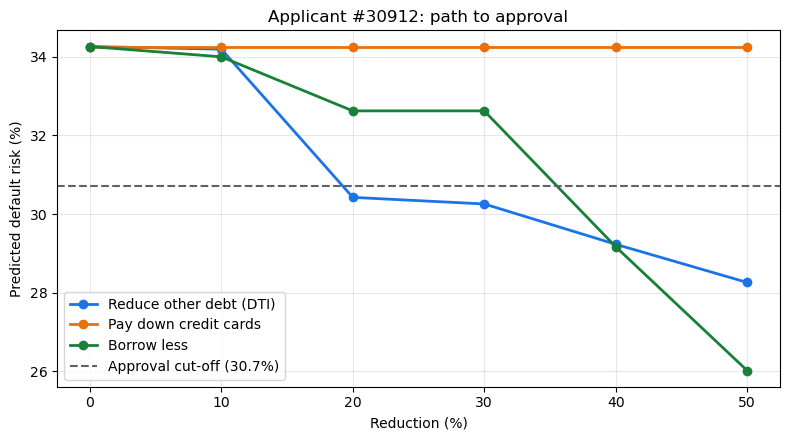

In [7]:
i = examples[0]
row = test_df.iloc[i]
plt.figure(figsize=(8, 4.5))
colors = ["#1a73e8", "#e8710a", "#188038"]
for k, name in enumerate(ACTION_NAMES):
    fr = np.zeros(len(ACTION_NAMES))
    risks = []
    for s in STEPS:
        fr[:] = 0
        fr[k] = s
        risks.append(model.predict_proba(prep.transform(pd.DataFrame([apply_changes(row, fr)])))[:, 1][0])
    plt.plot([s * 100 for s in STEPS], np.array(risks) * 100, marker="o", color=colors[k % 3], label=name, linewidth=2)
plt.axhline(THRESHOLD * 100, color="#5f6368", linestyle="--", label=f"Approval cut-off ({THRESHOLD:.1%})")
plt.xlabel("Reduction (%)")
plt.ylabel("Predicted default risk (%)")
plt.title(f"Applicant #{i}: path to approval")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "path_to_approval_example.png"), dpi=200)
plt.show()

## 6. Across many declined applicants

  100/500 done
  200/500 done
  300/500 done
  400/500 done
  500/500 done

Declined applicants checked: 500
Can be approved within the limits: 282 (56%)
  ...with one change:        61%
  ...with two or more:       39%

Which actions the solutions use:
                        used_in_solutions median_reduction_when_used
Reduce other debt (DTI)               58%                        30%
Pay down credit cards                 16%                        10%
Borrow less                           72%                        40%


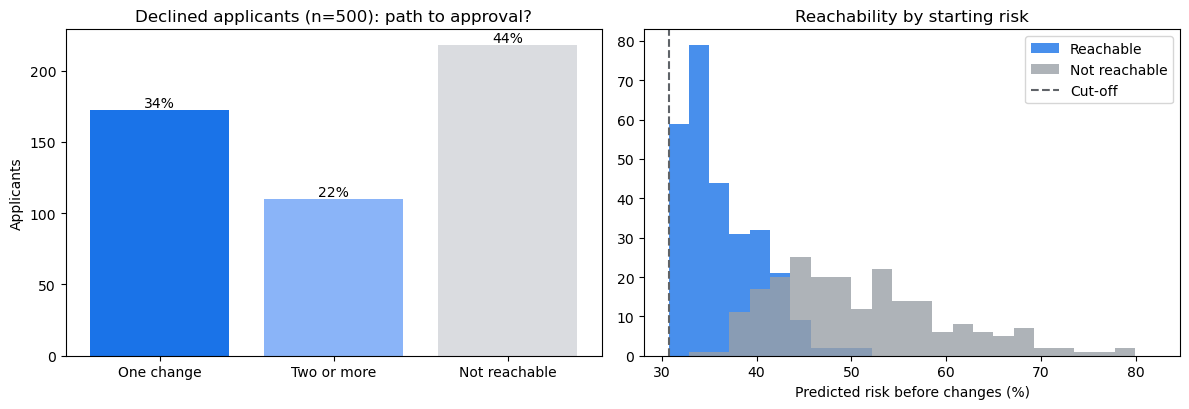

Outputs saved in: ../outputs/notebook10_outputs


In [8]:
N_EVAL = min(500, len(declined))
eval_idx = rng.choice(declined, size=N_EVAL, replace=False)
records = []
for n, i in enumerate(eval_idx, 1):
    fracs, new_p = counterfactual(i)
    rec = {"applicant": i, "risk_before": p_test[i], "reachable": fracs is not None, "risk_after": new_p}
    if fracs is not None:
        rec.update({name: f for name, f in zip(ACTION_NAMES, fracs)})
        rec["n_actions"] = int((fracs > 0).sum())
        rec["total_reduction"] = float(fracs.sum())
    records.append(rec)
    if n % 100 == 0:
        print(f"  {n}/{N_EVAL} done")
cf = pd.DataFrame(records)
cf.to_csv(os.path.join(SAVE_DIR, "counterfactuals_summary.csv"), index=False)

reach = cf[cf["reachable"]]
print(f"\nDeclined applicants checked: {N_EVAL}")
print(f"Can be approved within the limits: {len(reach)} ({len(reach) / N_EVAL:.0%})")
if len(reach):
    print(f"  ...with one change:        {(reach['n_actions'] == 1).mean():.0%}")
    print(f"  ...with two or more:       {(reach['n_actions'] >= 2).mean():.0%}")
    usage = {name: (reach[name] > 0).mean() for name in ACTION_NAMES}
    median_size = {name: reach.loc[reach[name] > 0, name].median() for name in ACTION_NAMES}
    summary = pd.DataFrame({"used_in_solutions": usage, "median_reduction_when_used": median_size})
    print("\nWhich actions the solutions use:")
    print(summary.to_string(formatters={"used_in_solutions": "{:.0%}".format,
                                        "median_reduction_when_used": lambda v: "-" if pd.isna(v) else f"{v:.0%}"}))
    summary.to_csv(os.path.join(SAVE_DIR, "action_usage.csv"))

# chart: how far from the cut-off vs whether reachable
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
cats = ["One change", "Two or more", "Not reachable"]
vals = [(reach["n_actions"] == 1).sum() if len(reach) else 0,
        (reach["n_actions"] >= 2).sum() if len(reach) else 0,
        (~cf["reachable"]).sum()]
axes[0].bar(cats, vals, color=["#1a73e8", "#8ab4f8", "#dadce0"])
for k, v in enumerate(vals):
    axes[0].text(k, v, f"{v / N_EVAL:.0%}", ha="center", va="bottom")
axes[0].set_title(f"Declined applicants (n={N_EVAL}): path to approval?")
axes[0].set_ylabel("Applicants")
bins = np.linspace(cf["risk_before"].min(), cf["risk_before"].max(), 25)
axes[1].hist(cf.loc[cf["reachable"], "risk_before"] * 100, bins=bins * 100, alpha=0.8, label="Reachable", color="#1a73e8")
axes[1].hist(cf.loc[~cf["reachable"], "risk_before"] * 100, bins=bins * 100, alpha=0.8, label="Not reachable", color="#9aa0a6")
axes[1].axvline(THRESHOLD * 100, color="#5f6368", linestyle="--", label="Cut-off")
axes[1].set_xlabel("Predicted risk before changes (%)")
axes[1].set_title("Reachability by starting risk")
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "counterfactual_summary.png"), dpi=200)
plt.show()

joblib.dump({"model": model, "features": FEATURES, "threshold": THRESHOLD},
            os.path.join(SAVE_DIR, "xgb_counterfactual_model.joblib"))
print("Outputs saved in:", SAVE_DIR)